In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from src.data_loader import load_data, remove_nulls,show_duplicates,fill_nulls
from src.analysis import calculate_ema,calculate_sma,calculate_rsi,identify_rsi_signals,calculate_macd,calculate_macd_last_2_years,calculate_bollinger_bands,calculate_volatility,calculate_max_drawdown,calculate_bollinger_bands_2years
from src.plot import plot_bollinger_bands,plot_volatility,plot_price_with_moving_averages,plot_price_with_bollinger_bands



# LOAD DATA

In [25]:
df = load_data("../data/raw/Data/AMZN.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


#  DATA PREPARATION

In [26]:

# 1. Normalize timestamps (convert to timezone-naive)
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# make timezone-naive
df['Date'] = df['Date'].dt.tz_localize(None)

# verify
print(df['Date'].head())

# 2. Ensure columns are correctly typed
df = df.astype({'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'float64'})

0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


# HANDLE MISSING VALUES


In [27]:
df = fill_nulls(df)
df = remove_nulls(df)
df.head()

No missing values found.


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No missing values found. All 3774 rows kept.


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000.0
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000.0
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000.0
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000.0
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000.0


# Technical Indicators with TA-Lib

In [28]:
df = df.sort_values('Date')
df = calculate_sma(
    df,
    column='Close',
    windows=[20,50,100]
)

# calculate EMA
df = calculate_ema(
    df,
    column='Close',
    windows=[20,50,100]
)

# display results
print(df.tail(20))

           Date       Close        High         Low        Open       Volume  \
3754 2023-12-01  147.029999  147.250000  145.550003  146.000000   39951800.0   
3755 2023-12-04  144.839996  145.350006  142.809998  145.250000   48294200.0   
3756 2023-12-05  146.880005  148.570007  143.130005  143.550003   46822400.0   
3757 2023-12-06  144.520004  147.850006  144.279999  147.580002   39679000.0   
3758 2023-12-07  146.880005  147.919998  145.339996  146.149994   52352800.0   
3759 2023-12-08  147.419998  147.839996  145.399994  145.479996   41906000.0   
3760 2023-12-11  145.889999  146.190002  143.639999  145.660004   50907300.0   
3761 2023-12-12  147.479996  147.500000  145.300003  145.520004   44944300.0   
3762 2023-12-13  148.839996  149.460007  146.820007  148.119995   52766200.0   
3763 2023-12-14  147.419998  150.539993  145.520004  149.929993   58400800.0   
3764 2023-12-15  149.970001  150.570007  147.880005  148.380005  110089300.0   
3765 2023-12-18  154.070007  154.850006 

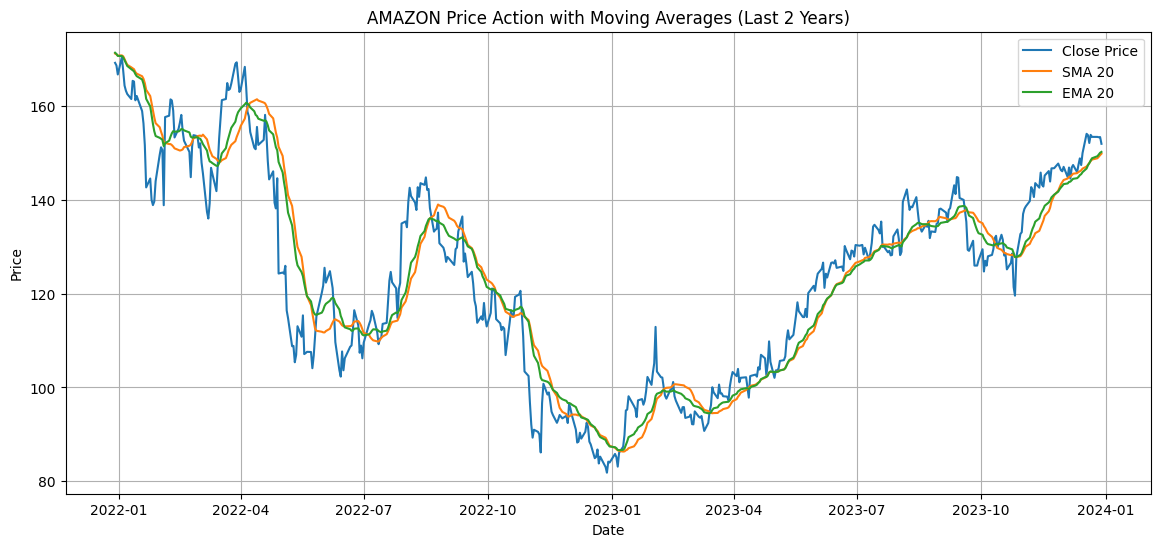

In [30]:
plot_price_with_moving_averages(
    df,
    ticker='AMAZON'
)

### Moving Average Analysis Summary

- The stock showed a strong long-term upward trend, especially after 2019.
- SMA and EMA closely followed the closing price, confirming the overall market direction.
- EMA reacted more quickly to short-term price fluctuations, while SMA appeared smoother and lagged slightly behind price movements.
- Periods where moving averages moved sharply upward reflected strong bullish momentum and increased market activity.
- Higher volatility was observed between 2020 and 2023, with larger price swings and rapid trend changes.

### Relative Strength Index(RSI)

In [31]:
df = calculate_rsi(
    df,
    column='Close',
    period=14
)

In [32]:
df = identify_rsi_signals(df)

print(
    df[
        ['Date', 'Close', 'RSI', 'Overbought', 'Oversold']
    ].tail(20)
)

           Date       Close        RSI  Overbought  Oversold
3754 2023-12-01  147.029999  62.643815       False     False
3755 2023-12-04  144.839996  56.668361       False     False
3756 2023-12-05  146.880005  60.452633       False     False
3757 2023-12-06  144.520004  54.520611       False     False
3758 2023-12-07  146.880005  58.867308       False     False
3759 2023-12-08  147.419998  59.813727       False     False
3760 2023-12-11  145.889999  55.889839       False     False
3761 2023-12-12  147.479996  58.906837       False     False
3762 2023-12-13  148.839996  61.342397       False     False
3763 2023-12-14  147.419998  57.509706       False     False
3764 2023-12-15  149.970001  62.090387       False     False
3765 2023-12-18  154.070007  68.053721       False     False
3766 2023-12-19  153.789993  67.275369       False     False
3767 2023-12-20  152.119995  62.671579       False     False
3768 2023-12-21  153.839996  65.305020       False     False
3769 2023-12-22  153.419

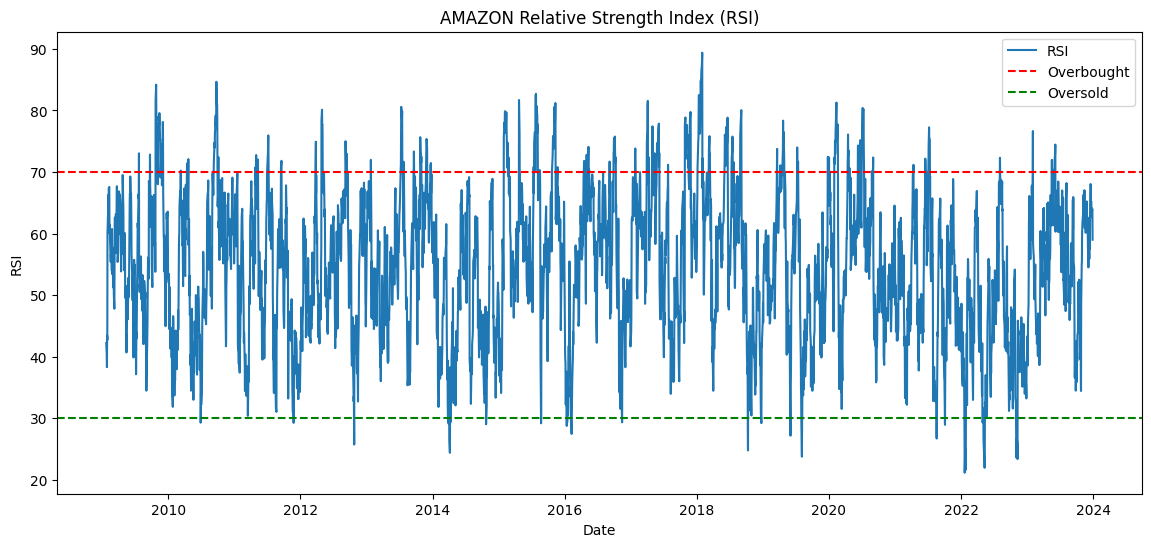

In [34]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['RSI'],
    label='RSI'
)

# overbought line
plt.axhline(
    70,
    color='red',
    linestyle='--',
    label='Overbought'
)

# oversold line
plt.axhline(
    30,
    color='green',
    linestyle='--',
    label='Oversold'
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.title("AMAZON Relative Strength Index (RSI)")

plt.legend()

plt.show()

#### RSI Analysis Summary

- The RSI fluctuated frequently between overbought and oversold levels, indicating changing market momentum over time.
- Several periods crossed above the 70 threshold, suggesting temporary overbought conditions and potential price pullbacks.
- Multiple dips below the 30 threshold indicated oversold conditions, which may signal possible buying opportunities or price rebounds.
- Most RSI values remained within the neutral range (30–70), reflecting normal market trading behavior during much of the period.

### MACD (Moving Average Convergence Divergence)


#### MACD For The Last 2 Years

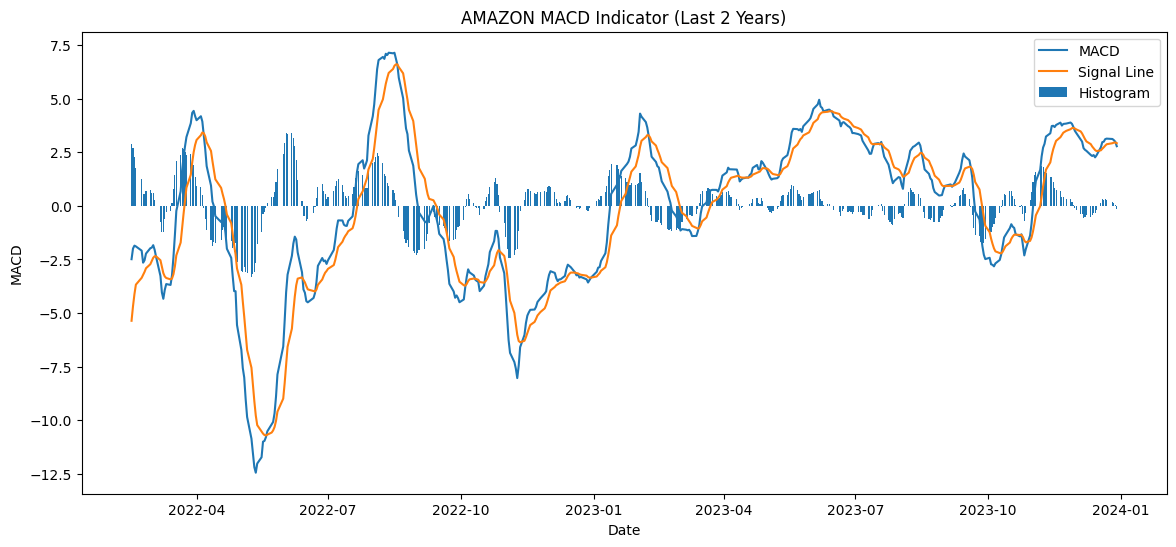

In [38]:
# calculate MACD for last 2 years
macd_df = calculate_macd_last_2_years(df)
plt.figure(figsize=(14,6))

# MACD line
plt.plot(
    macd_df['Date'],
    macd_df['MACD'],
    label='MACD'
)

# Signal line
plt.plot(
    macd_df['Date'],
    macd_df['MACD_Signal'],
    label='Signal Line'
)

# Histogram
plt.bar(
    macd_df['Date'],
    macd_df['MACD_Histogram'],
    label='Histogram'
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.title("AMAZON MACD Indicator (Last 2 Years)")

plt.legend()

plt.show()

#### MACD Comparison Summary

- The 2-year MACD chart shows recent market movements more clearly than the full historical chart.
- Several crossings between the MACD and signal line show frequent changes between upward and downward trends.
- Strong upward momentum appeared during parts of 2022 and 2023, while some periods showed clear downward pressure.
- Compared to the previous chart, the shorter timeframe makes recent market trends and momentum changes easier to see.

# Financial Metrics

### Volatility
Measures how much stock prices fluctuate over time using the standard deviation of returns. Higher volatility indicates higher risk.

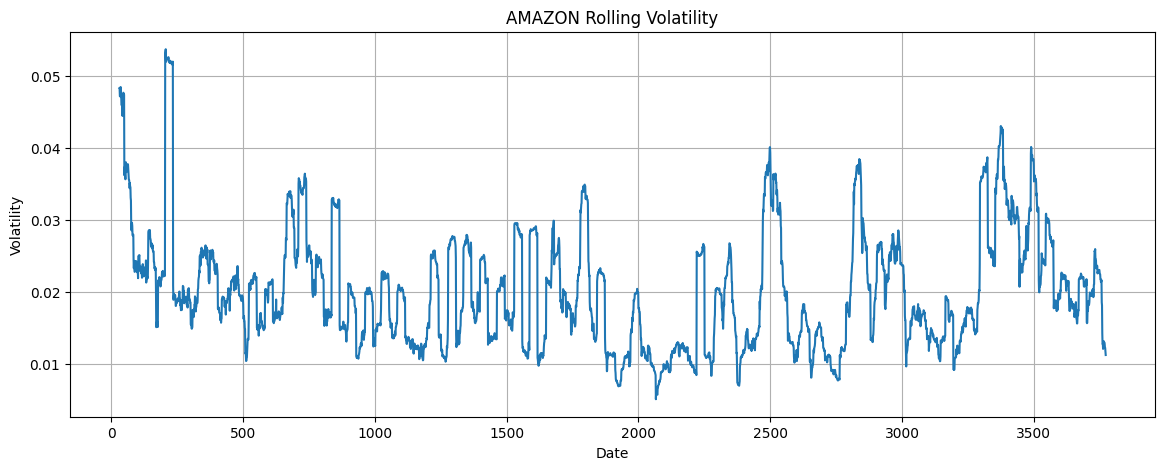

In [39]:
df = calculate_volatility(df)
plot_volatility(df, "AMAZON")

#### Rolling Volatility Analysis

The rolling volatility analysis for AAPL over the last two years shows generally moderate market fluctuations, with volatility mostly ranging between 0.01 and 0.03. Several short-term spikes were observed, including a major peak above 0.06, indicating periods of increased market uncertainty and strong price movements. Toward the end of the period, volatility declined and stabilized, suggesting reduced market risk and calmer trading conditions.

### Bollinger Bands
A volatility indicator consisting of upper and lower bands around a moving average to identify overbought or oversold conditions.

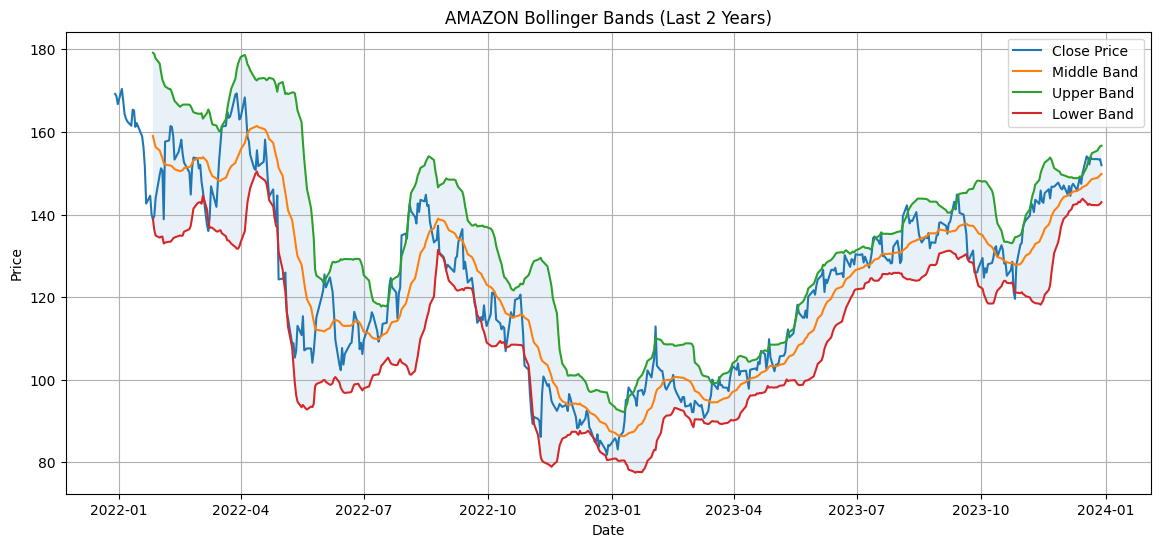

In [40]:
# Calculate Bollinger Bands
df_bollinger = calculate_bollinger_bands_2years(
    df,
    price_column='Close',
    date_column='Date',
    window=20,
    num_std=2
)
# Plot
plot_bollinger_bands(
    df_bollinger,
    ticker='AMAZON',
    price_column='Close',
    date_column='Date',
    window=20
)

#### Bollinger Bands Analysis

The Bollinger Bands analysis for AAPL over the latest two years shows periods of both high and low market volatility. Wider bands indicate increased price fluctuations and higher market uncertainty, particularly during strong upward and downward price movements. Narrower bands reflect more stable trading periods with lower volatility. The stock price frequently moved near the upper band during bullish trends and near the lower band during market declines, highlighting changing market momentum throughout the period.